# Module 4 — Robustness Analysis and Credit-Review Prioritisation

This notebook tests the selected Module 3 prediction pipeline under three sources of uncertainty: policy measurement, supply-chain incompleteness, and firm financial data. The saved Module 3 OOF results are reproduced first, then each uncertainty source is perturbed separately.

- **Part A** — Lineage reproduction
- **Part B** — Policy measurement uncertainty
- **Part C** — Network incompleteness
- **Part D** — Financial data uncertainty
- **Part E** — Credit-review prioritisation
- **Part F** — Robustness comparison


In [1]:
# Environment and configuration

from pathlib import Path
import json
import warnings
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score

warnings.filterwarnings("ignore")

RANDOM_SEED = 42

# Thesis runs use 300 Monte Carlo repetitions.
N_REPS_POLICY = 300
N_REPS_NETWORK = 300
N_REPS_FINANCIAL = 300

POLICY_LEVELS = [0.05, 0.10, 0.20, 0.30]
NETWORK_LEVELS = [0.05, 0.10, 0.20, 0.30]
FINANCIAL_LEVELS = [0.05, 0.10, 0.20]

CHAIN_LEADER_SHARE = 0.05
PROBABILITY_TOLERANCE = 1e-10

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)


Python: 3.12.10
pandas: 3.0.2
numpy: 2.4.4


## Part A — Lineage Reproduction

The final Module 3 feature order, temporal folds, preprocessing, and selected model are reconstructed before the robustness experiments. The saved OOF predictions must pass the lineage check before the remaining parts are run.


In [2]:
# A1. Inputs and feature definitions

BASE_DIR = Path(".")

FILES = {
    "m3_panel": BASE_DIR / "module3_final_firm_year_panel.csv",
    "m3_selection": BASE_DIR / "module3_selected_model.json",
    "m3_predictions": BASE_DIR / "module3_best_model_predictions.csv",
    "edges": BASE_DIR / "10_hybrid_supplier_customer_edges_6000.csv",
}

missing = [str(path) for path in FILES.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required Module 4 inputs:\n- " + "\n- ".join(missing)
    )

FINANCIAL_FEATURES = [
    "log_assets",
    "revenue_growth",
    "roa",
    "leverage",
    "cash_ratio",
    "rd_intensity",
    "capex_intensity",
    "interest_coverage",
]

NETWORK_FEATURES = ["is_chain_leader"]

POLICY_FEATURES = [
    "policy_exposure_primary",
    "lagged_policy_exposure",
]

# Keep the same feature order used by the final Module 3 model.
FEATURE_SETS = {
    "B1_Financial_ChainLeader":
        FINANCIAL_FEATURES + NETWORK_FEATURES,
    "B2_Financial_ChainLeader_Policy":
        FINANCIAL_FEATURES + NETWORK_FEATURES + POLICY_FEATURES,
}

panel = pd.read_csv(FILES["m3_panel"], encoding="utf-8-sig")
saved_preds = pd.read_csv(FILES["m3_predictions"], encoding="utf-8-sig")

with open(FILES["m3_selection"], "r", encoding="utf-8") as f:
    selection = json.load(f)

if "year" not in panel.columns and "feature_year" in panel.columns:
    panel = panel.rename(columns={"feature_year": "year"})
if "year" not in saved_preds.columns and "feature_year" in saved_preds.columns:
    saved_preds = saved_preds.rename(columns={"feature_year": "year"})

required_panel_cols = {"firm_id", "year", "target_class"}
missing_cols = sorted(required_panel_cols - set(panel.columns))
if missing_cols:
    raise KeyError(f"Module 3 panel is missing required columns: {missing_cols}")

feature_set_name = selection.get("feature_set")
if feature_set_name not in FEATURE_SETS:
    raise KeyError(
        f"Unknown Module 3 feature set: {feature_set_name!r}. "
        f"Expected one of {list(FEATURE_SETS)}."
    )

SELECTED_FEATURES = FEATURE_SETS[feature_set_name]
missing_features = [c for c in SELECTED_FEATURES if c not in panel.columns]
if missing_features:
    raise KeyError(
        f"Selected features are missing from the Module 3 panel: {missing_features}"
    )

panel["year"] = panel["year"].astype(int)
saved_preds["year"] = saved_preds["year"].astype(int)

print("Selected feature set:", feature_set_name)
print("Selected model:", selection.get("model_family"), selection.get("params", {}))
print("Panel shape:", panel.shape)


Selected feature set: B2_Financial_ChainLeader_Policy
Selected model: LogisticRegression {'C': 0.1, 'class_weight': None, 'penalty': 'l1', 'solver': 'saga'}
Panel shape: (9000, 33)


In [3]:
# A2. Module 3 reconstruction helpers

GLOBAL_CLASSES = np.array([0, 1, 2], dtype=int)

FOLDS = [
    {"train_years": [2019, 2020], "test_year": 2021},
    {"train_years": [2019, 2020, 2021], "test_year": 2022},
    {"train_years": [2019, 2020, 2021, 2022], "test_year": 2023},
    {"train_years": [2019, 2020, 2021, 2022, 2023], "test_year": 2024},
]


def make_preprocessing_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])


def aligned_predict_proba(model, X):
    """Align predicted probabilities to the fixed class order 0, 1, 2."""
    raw = model.predict_proba(X)
    model_classes = np.asarray(model.classes_, dtype=int)

    out = np.zeros((len(X), len(GLOBAL_CLASSES)), dtype=float)
    for j, cls in enumerate(model_classes):
        pos = np.where(GLOBAL_CLASSES == cls)[0]
        if len(pos) == 1:
            out[:, pos[0]] = raw[:, j]

    out = np.clip(out, 1e-12, 1.0)
    return out / out.sum(axis=1, keepdims=True)


def build_model_from_selection(selection_dict):
    """Rebuild the selected Module 3 logistic-regression specification."""
    model_family = selection_dict.get(
        "model_family",
        selection_dict.get("model"),
    )
    if model_family != "LogisticRegression":
        raise ValueError(
            "Module 4 expects the selected Module 3 model to be "
            f"LogisticRegression, got {model_family!r}."
        )

    params = {
        "solver": "lbfgs",
        "C": 1.0,
        "max_iter": 5000,
        "random_state": RANDOM_SEED,
    }
    params.update(selection_dict.get("params", {}))
    return LogisticRegression(**params)


def standardise_saved_prediction_columns(df):
    out = df.copy()

    aliases = {
        "target_class": "true_class",
        "pred_class": "predicted_class",
        "prediction": "predicted_class",
        "prob_class_0": "proba_class_0",
        "prob_class_1": "proba_class_1",
        "prob_class_2": "proba_class_2",
    }
    for old, new in aliases.items():
        if old in out.columns and new not in out.columns:
            out = out.rename(columns={old: new})

    required = [
        "firm_id",
        "year",
        "outcome_year",
        "true_class",
        "predicted_class",
        "fold",
        "proba_class_0",
        "proba_class_1",
        "proba_class_2",
    ]
    missing = [c for c in required if c not in out.columns]
    if missing:
        raise KeyError(f"Saved Module 3 predictions are missing columns: {missing}")

    for col in ["year", "outcome_year", "fold", "true_class", "predicted_class"]:
        out[col] = out[col].astype(int)

    return out


def rebuild_module3_oof(panel_df, selection_dict, saved_preds=None):
    """Rebuild all Module 3 OOF predictions with the original temporal folds."""
    feature_set = selection_dict.get("feature_set")
    if feature_set not in FEATURE_SETS:
        raise ValueError(
            f"Unknown feature_set: {feature_set!r}. "
            f"Expected one of {list(FEATURE_SETS)}."
        )

    features = FEATURE_SETS[feature_set]
    required = features + [
        "firm_id",
        "year",
        "outcome_year",
        "target_class",
    ]
    missing = [c for c in required if c not in panel_df.columns]
    if missing:
        raise KeyError(f"Module 3 panel is missing columns: {missing}")

    oof_parts = []

    for fold_idx, fold in enumerate(FOLDS, start=1):
        train_mask = panel_df["year"].isin(fold["train_years"])
        test_mask = panel_df["year"].eq(fold["test_year"])

        X_train_raw = panel_df.loc[train_mask, features].to_numpy()
        X_test_raw = panel_df.loc[test_mask, features].to_numpy()
        y_train = panel_df.loc[train_mask, "target_class"].to_numpy(dtype=int)
        y_test = panel_df.loc[test_mask, "target_class"].to_numpy(dtype=int)

        # Fit preprocessing on historical training years only.
        preproc = make_preprocessing_pipeline()
        X_train = preproc.fit_transform(X_train_raw)
        X_test = preproc.transform(X_test_raw)

        model = build_model_from_selection(selection_dict)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test).astype(int)
        proba = aligned_predict_proba(model, X_test)

        part = pd.DataFrame({
            "firm_id": panel_df.loc[test_mask, "firm_id"].to_numpy(),
            "year": panel_df.loc[test_mask, "year"].to_numpy(dtype=int),
            "outcome_year": panel_df.loc[test_mask, "outcome_year"].to_numpy(dtype=int),
            "true_class": y_test,
            "predicted_class": y_pred,
            "fold": fold_idx,
            "proba_class_0": proba[:, 0],
            "proba_class_1": proba[:, 1],
            "proba_class_2": proba[:, 2],
        })
        oof_parts.append(part)

    return pd.concat(oof_parts, ignore_index=True)


def compare_module3_oof(
    saved_predictions,
    rebuilt_oof,
    probability_tolerance=PROBABILITY_TOLERANCE,
):
    """Compare saved and rebuilt OOF predictions before perturbation tests."""
    saved = standardise_saved_prediction_columns(saved_predictions)
    rebuilt = standardise_saved_prediction_columns(rebuilt_oof)

    keys = ["firm_id", "year", "outcome_year", "fold"]

    if saved.duplicated(keys).any():
        raise ValueError("Duplicate keys in saved Module 3 OOF predictions.")
    if rebuilt.duplicated(keys).any():
        raise ValueError("Duplicate keys in rebuilt Module 3 OOF predictions.")

    merged = saved.merge(
        rebuilt,
        on=keys,
        how="outer",
        suffixes=("_saved", "_rebuilt"),
        indicator=True,
    )

    key_match = bool(merged["_merge"].eq("both").all())
    both = merged.loc[merged["_merge"].eq("both")].copy()

    true_mismatch = int(
        (both["true_class_saved"] != both["true_class_rebuilt"]).sum()
    )
    pred_mismatch = int(
        (both["predicted_class_saved"] != both["predicted_class_rebuilt"]).sum()
    )

    max_probability_difference = 0.0
    for col in ["proba_class_0", "proba_class_1", "proba_class_2"]:
        difference = np.abs(
            both[f"{col}_saved"].to_numpy(dtype=float)
            - both[f"{col}_rebuilt"].to_numpy(dtype=float)
        )
        if len(difference):
            max_probability_difference = max(
                max_probability_difference,
                float(np.nanmax(difference)),
            )

    lineage_pass = (
        key_match
        and len(saved) == len(rebuilt) == len(both)
        and true_mismatch == 0
        and pred_mismatch == 0
        and max_probability_difference <= probability_tolerance
    )

    check = {
        "saved_rows": len(saved),
        "rebuilt_rows": len(rebuilt),
        "matched_rows": len(both),
        "key_match": key_match,
        "true_class_mismatch_n": true_mismatch,
        "predicted_class_mismatch_n": pred_mismatch,
        "predicted_class_mismatch_rate":
            pred_mismatch / len(both) if len(both) else np.nan,
        "max_probability_difference": max_probability_difference,
        "probability_tolerance": probability_tolerance,
        "lineage_pass": lineage_pass,
    }

    return check, merged


In [4]:
# A3. Rebuild and verify saved Module 3 OOF predictions

rebuilt_oof = rebuild_module3_oof(
    panel_df=panel,
    selection_dict=selection,
    saved_preds=saved_preds,
)

lineage_check, _ = compare_module3_oof(
    saved_predictions=saved_preds,
    rebuilt_oof=rebuilt_oof,
    probability_tolerance=PROBABILITY_TOLERANCE,
)

lineage_df = pd.DataFrame([lineage_check])
lineage_df.to_csv(
    "module4_lineage_check.csv",
    index=False,
    encoding="utf-8-sig",
)
display(lineage_df)

if not lineage_check["lineage_pass"]:
    raise RuntimeError(
        "Module 3 lineage reproduction failed. "
        f"Prediction mismatches: {lineage_check['predicted_class_mismatch_n']}; "
        f"max probability difference: "
        f"{lineage_check['max_probability_difference']:.3e}."
    )

baseline_oof = standardise_saved_prediction_columns(saved_preds).copy()
baseline_oof["year"] = baseline_oof["year"].astype(int)

BASELINE_MACRO_F1 = f1_score(
    baseline_oof["true_class"],
    baseline_oof["predicted_class"],
    average="macro",
    zero_division=0,
)
BASELINE_BA = balanced_accuracy_score(
    baseline_oof["true_class"],
    baseline_oof["predicted_class"],
)

print("Lineage reproduction: PASS")
print(f"Baseline Macro-F1: {BASELINE_MACRO_F1:.6f}")
print(f"Baseline Balanced Accuracy: {BASELINE_BA:.6f}")


,saved_rows,rebuilt_rows,matched_rows,key_match,true_class_mismatch_n,predicted_class_mismatch_n,predicted_class_mismatch_rate,max_probability_difference,probability_tolerance,lineage_pass
0,6000,6000,6000,True,0,0,0.0,1.110223e-16,1.000000e-10,True


Lineage reproduction: PASS
Baseline Macro-F1: 0.666394
Baseline Balanced Accuracy: 0.661352


In [5]:
# Shared robustness helpers

def predict_oof_from_panel(perturbed_panel, selection_dict, template_saved_oof):
    """Refit the selected model fold-by-fold on a perturbed panel."""
    return rebuild_module3_oof(
        panel_df=perturbed_panel,
        selection_dict=selection_dict,
        saved_preds=template_saved_oof,
    )


def align_to_baseline(baseline_df, perturbed_df):
    base = standardise_saved_prediction_columns(baseline_df).copy()
    pert = standardise_saved_prediction_columns(perturbed_df).copy()

    key = ["firm_id", "year"]
    keep = key + ["true_class", "predicted_class"]

    return base[keep].merge(
        pert[keep],
        on=key,
        how="inner",
        suffixes=("_base", "_pert"),
        validate="one_to_one",
    )


def robustness_metrics(baseline_df, perturbed_df):
    """Return the prediction metrics used in the robustness summaries."""
    merged = align_to_baseline(baseline_df, perturbed_df)

    y_true = merged["true_class_base"].astype(int)
    y_pred = merged["predicted_class_pert"].astype(int)

    return {
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
        "classification_flip_rate": np.mean(
            merged["predicted_class_base"].astype(int).to_numpy()
            != merged["predicted_class_pert"].astype(int).to_numpy()
        ),
    }


def exact_top_share_flags(score_series, firm_ids, share=0.05):
    """Select an exact top share using firm_id as a deterministic tie-break."""
    tmp = pd.DataFrame({
        "firm_id": pd.Series(firm_ids).astype(str).to_numpy(),
        "score": np.asarray(score_series, dtype=float),
    })
    tmp = tmp.sort_values(
        ["score", "firm_id"],
        ascending=[False, True],
        kind="mergesort",
    ).reset_index(drop=True)

    k = max(1, int(round(len(tmp) * share)))
    selected = set(tmp.iloc[:k]["firm_id"])

    return pd.Series(
        pd.Series(firm_ids).astype(str).isin(selected).astype(int).to_numpy()
    )


def detect_edge_columns(edges_df):
    """Detect supplier/source and customer/target columns in the edge list."""
    source_candidates = [
        "supplier_firm_id",
        "supplier_id",
        "supplier",
        "source_firm_id",
        "source_id",
        "source",
        "from_firm_id",
        "from_id",
        "from",
    ]
    target_candidates = [
        "customer_firm_id",
        "customer_id",
        "customer",
        "target_firm_id",
        "target_id",
        "target",
        "to_firm_id",
        "to_id",
        "to",
    ]

    source_col = next(
        (c for c in source_candidates if c in edges_df.columns),
        None,
    )
    target_col = next(
        (c for c in target_candidates if c in edges_df.columns),
        None,
    )

    if source_col is None or target_col is None:
        raise KeyError(
            "Could not identify supplier/customer edge columns. "
            f"Available columns: {list(edges_df.columns)}"
        )

    return source_col, target_col


## Part B — Policy Measurement Uncertainty

Policy exposure is perturbed at the industry-year level, then the selected model is refitted on the same expanding-window folds. The experiment measures prediction sensitivity to policy-measurement error.


In [6]:
# B1. Policy uncertainty

def perturb_policy_features(panel_df, level, rng):
    out = panel_df.copy()

    group_cols = (
        ["industry_code", "year"]
        if "industry_code" in out.columns
        else ["year"]
    )

    # Use one multiplier for each shared policy-exposure unit.
    group_keys = out[group_cols].drop_duplicates().reset_index(drop=True)
    group_keys["_policy_multiplier"] = rng.normal(
        1.0, level, size=len(group_keys)
    ).clip(min=0.0)

    out = out.merge(group_keys, on=group_cols, how="left")
    out["policy_exposure_primary"] = (
        out["policy_exposure_primary"].astype(float)
        * out["_policy_multiplier"].astype(float)
    ).clip(lower=0.0)

    # Rebuild the lagged exposure from the perturbed current exposure.
    if "industry_code" in out.columns:
        unique_exp = (
            out[["industry_code", "year", "policy_exposure_primary"]]
            .drop_duplicates(["industry_code", "year"])
            .sort_values(["industry_code", "year"])
        )
        unique_exp["lagged_policy_exposure_pert"] = (
            unique_exp.groupby("industry_code")["policy_exposure_primary"].shift(1)
        )

        out = out.merge(
            unique_exp[
                ["industry_code", "year", "lagged_policy_exposure_pert"]
            ],
            on=["industry_code", "year"],
            how="left",
        )
        out["lagged_policy_exposure"] = out[
            "lagged_policy_exposure_pert"
        ].where(
            out["lagged_policy_exposure_pert"].notna(),
            out["lagged_policy_exposure"],
        )
        out = out.drop(columns=["lagged_policy_exposure_pert"])
    else:
        lag_multiplier = rng.normal(1.0, level, size=len(out))
        lag_multiplier = np.clip(lag_multiplier, 0.0, None)
        out["lagged_policy_exposure"] = (
            out["lagged_policy_exposure"].astype(float) * lag_multiplier
        ).clip(lower=0.0)

    return out.drop(columns=["_policy_multiplier"], errors="ignore")


policy_rows = []

for level in POLICY_LEVELS:
    for rep in range(N_REPS_POLICY):
        rng = np.random.default_rng(
            RANDOM_SEED + 10_000 + rep + int(level * 10_000)
        )
        pert_panel = perturb_policy_features(panel, level, rng)
        pert_oof = predict_oof_from_panel(pert_panel, selection, saved_preds)
        metrics = robustness_metrics(baseline_oof, pert_oof)

        policy_rows.append({
            "uncertainty_source": "policy_measurement",
            "level": level,
            "rep": rep,
            **metrics,
        })

policy_results = pd.DataFrame(policy_rows)
policy_results.to_csv(
    "module4_policy_uncertainty.csv",
    index=False,
    encoding="utf-8-sig",
)

policy_summary = (
    policy_results
    .groupby("level")
    .agg(
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_sd=("macro_f1", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        flip_rate_mean=("classification_flip_rate", "mean"),
    )
    .reset_index()
)

display(policy_summary)


,level,macro_f1_mean,macro_f1_sd,balanced_accuracy_mean,flip_rate_mean
0,0.05,0.666120,0.002136,0.661769,0.020979
1,0.10,0.667024,0.002711,0.663764,0.041011
2,0.20,0.665960,0.003571,0.663777,0.072941
3,0.30,0.663212,0.004695,0.660581,0.095711


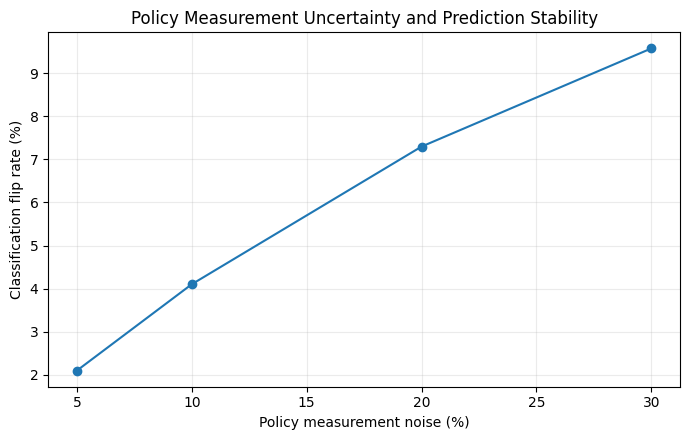

In [7]:
# Policy uncertainty figure

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(
    policy_summary["level"] * 100,
    policy_summary["flip_rate_mean"] * 100,
    marker="o",
)
ax.set_xlabel("Policy measurement noise (%)")
ax.set_ylabel("Classification flip rate (%)")
ax.set_title("Policy Measurement Uncertainty and Prediction Stability")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(
    "module4_fig1_policy_uncertainty.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## Part C — Network Incompleteness

Supply-chain edges are randomly removed, out-degree is recomputed, and the exact top-5% chain-leader flag is reassigned. The selected prediction model is then refitted with the perturbed network feature.


In [8]:
# C1. Baseline network reconstruction

edges = pd.read_csv(FILES["edges"], encoding="utf-8-sig")
source_col, target_col = detect_edge_columns(edges)

edges["_supplier_key"] = edges[source_col].astype(str)
edges["_customer_key"] = edges[target_col].astype(str)

firm_keys = pd.Index(panel["firm_id"].astype(str).unique())
n_firms = len(firm_keys)

baseline_out_degree = (
    edges.groupby("_supplier_key").size()
    .reindex(firm_keys, fill_value=0)
    .astype(float)
)

baseline_chain_flags = exact_top_share_flags(
    baseline_out_degree.to_numpy(),
    baseline_out_degree.index.to_numpy(),
    share=CHAIN_LEADER_SHARE,
)
baseline_chain_map = pd.Series(
    baseline_chain_flags.to_numpy(),
    index=baseline_out_degree.index,
)

panel_chain = (
    panel[["firm_id", "is_chain_leader"]]
    .drop_duplicates("firm_id")
    .assign(_key=lambda x: x["firm_id"].astype(str))
    .set_index("_key")["is_chain_leader"]
    .astype(int)
    .reindex(firm_keys)
)

baseline_chain_mismatch = float(
    np.mean(
        baseline_chain_map.reindex(firm_keys).astype(int).to_numpy()
        != panel_chain.astype(int).to_numpy()
    )
)

print("Detected edge columns:", source_col, "->", target_col)
print("Number of firms:", n_firms)
print("Baseline chain leaders:", int(baseline_chain_map.sum()))
print(f"Chain-leader mismatch: {baseline_chain_mismatch:.4%}")

if baseline_chain_mismatch != 0.0:
    raise AssertionError(
        "The edge list does not reproduce the chain-leader indicator "
        "in the final Module 3 panel."
    )


Detected edge columns: supplier_firm_id -> customer_firm_id
Number of firms: 1500
Baseline chain leaders: 75
Chain-leader mismatch: 0.0000%


In [9]:
# C2. Edge-deletion robustness

network_rows = []

for level in NETWORK_LEVELS:
    keep_share = 1.0 - level

    for rep in range(N_REPS_NETWORK):
        rng = np.random.default_rng(
            RANDOM_SEED + 20_000 + rep + int(level * 10_000)
        )

        keep_mask = rng.random(len(edges)) < keep_share
        pert_edges = edges.loc[keep_mask].copy()

        pert_out_degree = (
            pert_edges.groupby("_supplier_key").size()
            .reindex(firm_keys, fill_value=0)
            .astype(float)
        )

        pert_chain_flags = exact_top_share_flags(
            pert_out_degree.to_numpy(),
            pert_out_degree.index.to_numpy(),
            share=CHAIN_LEADER_SHARE,
        )
        pert_chain_map = pd.Series(
            pert_chain_flags.to_numpy(),
            index=pert_out_degree.index,
        )

        # Structural stability before passing the perturbed flag to Module 3.
        rho = spearmanr(
            baseline_out_degree.to_numpy(),
            pert_out_degree.to_numpy(),
        ).statistic

        base_leaders = set(
            baseline_chain_map[baseline_chain_map == 1].index
        )
        pert_leaders = set(
            pert_chain_map[pert_chain_map == 1].index
        )
        leader_jaccard = (
            len(base_leaders & pert_leaders)
            / len(base_leaders | pert_leaders)
        )
        leader_flip = float(
            np.mean(
                baseline_chain_map.reindex(firm_keys).astype(int).to_numpy()
                != pert_chain_map.reindex(firm_keys).astype(int).to_numpy()
            )
        )

        pert_panel = panel.copy()
        pert_panel["_firm_key"] = pert_panel["firm_id"].astype(str)
        pert_panel["is_chain_leader"] = (
            pert_panel["_firm_key"].map(pert_chain_map).fillna(0).astype(int)
        )
        pert_panel = pert_panel.drop(columns=["_firm_key"])

        pert_oof = predict_oof_from_panel(
            pert_panel, selection, saved_preds
        )
        metrics = robustness_metrics(baseline_oof, pert_oof)

        network_rows.append({
            "uncertainty_source": "network_edge_deletion",
            "level": level,
            "rep": rep,
            "out_degree_spearman": rho,
            "chain_leader_jaccard": leader_jaccard,
            "chain_leader_flip_rate": leader_flip,
            **metrics,
        })

network_results = pd.DataFrame(network_rows)
network_results.to_csv(
    "module4_network_uncertainty.csv",
    index=False,
    encoding="utf-8-sig",
)

network_summary = (
    network_results
    .groupby("level")
    .agg(
        out_degree_spearman_mean=("out_degree_spearman", "mean"),
        chain_leader_jaccard_mean=("chain_leader_jaccard", "mean"),
        chain_leader_flip_mean=("chain_leader_flip_rate", "mean"),
        macro_f1_mean=("macro_f1", "mean"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        classification_flip_mean=("classification_flip_rate", "mean"),
    )
    .reset_index()
)

display(network_summary)


,level,out_degree_spearman_mean,chain_leader_jaccard_mean,chain_leader_flip_mean,macro_f1_mean,balanced_accuracy_mean,classification_flip_mean
0,0.05,0.977332,0.770337,0.013058,0.663428,0.657442,0.013413
1,0.10,0.953954,0.664821,0.020200,0.661355,0.655047,0.023816
2,0.20,0.903616,0.571017,0.027449,0.661553,0.655024,0.028752
3,0.30,0.849787,0.504739,0.033036,0.662195,0.655468,0.035217


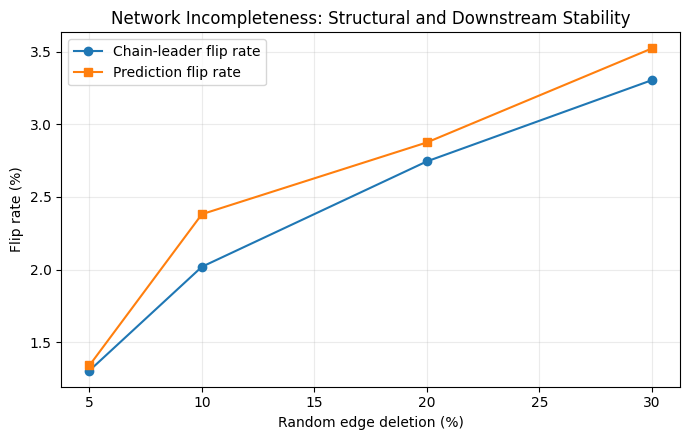

In [10]:
# Network uncertainty figure

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(
    network_summary["level"] * 100,
    network_summary["chain_leader_flip_mean"] * 100,
    marker="o",
    label="Chain-leader flip rate",
)
ax.plot(
    network_summary["level"] * 100,
    network_summary["classification_flip_mean"] * 100,
    marker="s",
    label="Prediction flip rate",
)
ax.set_xlabel("Random edge deletion (%)")
ax.set_ylabel("Flip rate (%)")
ax.set_title("Network Incompleteness: Structural and Downstream Stability")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(
    "module4_fig2_network_uncertainty.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## Part D — Financial Data Uncertainty

Financial variables receive feature-scaled noise and random missingness at each uncertainty level. Imputation and scaling are refitted within each training fold, while the targets remain unchanged.


In [11]:
# D1. Financial-data uncertainty

financial_scales = (
    panel[FINANCIAL_FEATURES]
    .std(numeric_only=True)
    .replace(0, 1.0)
    .fillna(1.0)
)


def perturb_financial_features(panel_df, level, rng):
    out = panel_df.copy()

    for col in FINANCIAL_FEATURES:
        values = out[col].astype(float).to_numpy(copy=True)
        sd = float(financial_scales[col])

        # Add measurement noise, then introduce missing observations.
        values += rng.normal(0.0, level * sd, size=len(values))
        missing = rng.random(len(values)) < level
        values[missing] = np.nan

        out[col] = values

    return out


financial_rows = []

for level in FINANCIAL_LEVELS:
    for rep in range(N_REPS_FINANCIAL):
        rng = np.random.default_rng(
            RANDOM_SEED + 30_000 + rep + int(level * 10_000)
        )
        pert_panel = perturb_financial_features(panel, level, rng)
        pert_oof = predict_oof_from_panel(pert_panel, selection, saved_preds)
        metrics = robustness_metrics(baseline_oof, pert_oof)

        financial_rows.append({
            "uncertainty_source": "financial_noise_missingness",
            "level": level,
            "rep": rep,
            **metrics,
        })

financial_results = pd.DataFrame(financial_rows)
financial_results.to_csv(
    "module4_financial_uncertainty.csv",
    index=False,
    encoding="utf-8-sig",
)

financial_summary = (
    financial_results
    .groupby("level")
    .agg(
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_sd=("macro_f1", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        flip_rate_mean=("classification_flip_rate", "mean"),
    )
    .reset_index()
)

display(financial_summary)


,level,macro_f1_mean,macro_f1_sd,balanced_accuracy_mean,flip_rate_mean
0,0.05,0.662362,0.002116,0.657398,0.033706
1,0.10,0.659837,0.002749,0.654905,0.055582
2,0.20,0.654682,0.003070,0.649517,0.089676


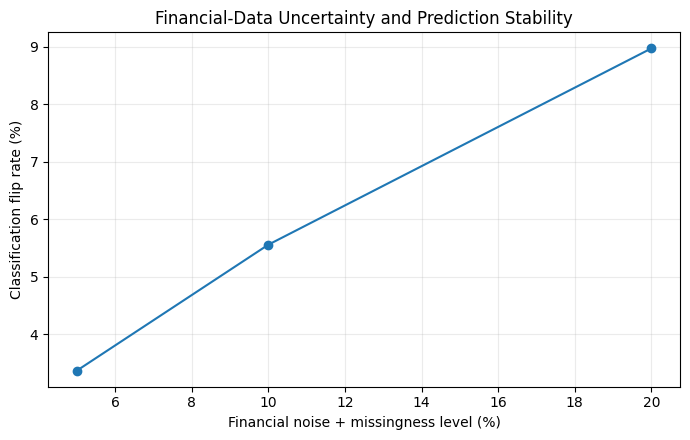

In [12]:
# Financial uncertainty figure

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(
    financial_summary["level"] * 100,
    financial_summary["flip_rate_mean"] * 100,
    marker="o",
)
ax.set_xlabel("Financial noise + missingness level (%)")
ax.set_ylabel("Classification flip rate (%)")
ax.set_title("Financial-Data Uncertainty and Prediction Stability")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(
    "module4_fig3_financial_uncertainty.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## Part E — Credit-Review Prioritisation

The latest OOF predictions and chain-leader status are combined into four compact review tiers. Within each tier, the class-2 model score is used only to order firms for review.


In [13]:
# E1. Credit-review prioritisation

preds_std = standardise_saved_prediction_columns(saved_preds).copy()
latest_year = int(preds_std["year"].max())

# Prediction columns come from the saved OOF file; the chain-leader flag comes
# from the final Module 3 panel.
prediction_cols = ["firm_id", "year", "predicted_class"]
probability_cols = [
    c for c in preds_std.columns
    if c.startswith("proba_")
]
prediction_cols += probability_cols

if "true_class" in preds_std.columns:
    prediction_cols.append("true_class")

prediction_cols = list(dict.fromkeys(prediction_cols))

latest_pred = preds_std.loc[
    preds_std["year"] == latest_year,
    prediction_cols,
].copy()

required_panel_cols = ["firm_id", "year", "is_chain_leader"]
missing_panel_cols = [
    c for c in required_panel_cols
    if c not in panel.columns
]
if missing_panel_cols:
    raise KeyError(
        f"Missing required columns in panel: {missing_panel_cols}"
    )

latest_panel = panel.loc[
    panel["year"] == latest_year,
    required_panel_cols,
].copy()

if latest_panel.duplicated(["firm_id", "year"]).any():
    raise ValueError("Duplicate firm-year rows in latest panel.")
if latest_pred.duplicated(["firm_id", "year"]).any():
    raise ValueError("Duplicate firm-year rows in latest predictions.")

credit_review = latest_panel.merge(
    latest_pred,
    on=["firm_id", "year"],
    how="inner",
    validate="one_to_one",
)

if "is_chain_leader" not in credit_review.columns:
    raise KeyError("is_chain_leader is missing after the merge.")

strong_class = 2
strong_prob_col = (
    "proba_class_2"
    if "proba_class_2" in credit_review.columns
    else None
)


def assign_review_tier(row):
    strong = int(row["predicted_class"]) == strong_class
    leader = int(row["is_chain_leader"]) == 1

    if strong and leader:
        return "Tier A - Strong response + Chain leader"
    if strong:
        return "Tier B - Strong response"
    if leader:
        return "Tier C - Chain leader review"
    return "Tier D - Standard review"


credit_review["review_tier"] = credit_review.apply(
    assign_review_tier,
    axis=1,
)

if strong_prob_col is not None:
    credit_review["priority_model_score"] = pd.to_numeric(
        credit_review[strong_prob_col],
        errors="coerce",
    ).fillna(0.0)
else:
    credit_review["priority_model_score"] = (
        credit_review["predicted_class"].astype(int) == strong_class
    ).astype(float)

tier_order = {
    "Tier A - Strong response + Chain leader": 1,
    "Tier B - Strong response": 2,
    "Tier C - Chain leader review": 3,
    "Tier D - Standard review": 4,
}

credit_review["_tier_order"] = credit_review["review_tier"].map(tier_order)

credit_review = (
    credit_review
    .sort_values(
        ["_tier_order", "priority_model_score", "firm_id"],
        ascending=[True, False, True],
    )
    .drop(columns="_tier_order")
    .reset_index(drop=True)
)

credit_review.to_csv(
    "module4_credit_review_priority.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Latest feature year:", latest_year)
print("Number of firms:", len(credit_review))

display(
    credit_review["review_tier"]
    .value_counts()
    .reindex(tier_order.keys(), fill_value=0)
    .rename_axis("review_tier")
    .reset_index(name="n_firms")
)

display(credit_review.head(20))


Latest feature year: 2024
Number of firms: 1500


,review_tier,n_firms
0,Tier A - Strong response + Chain leader,70
1,Tier B - Strong response,409
2,Tier C - Chain leader review,5
3,Tier D - Standard review,1016


,firm_id,year,is_chain_leader,predicted_class,proba_class_0,proba_class_1,proba_class_2,true_class,review_tier,priority_model_score
0,SYNF00306,2024,1,2,1.000000e-12,0.000160,0.999840,2,Tier A - Strong response + Chain leader,0.999840
1,SYNF00317,2024,1,2,1.000000e-12,0.000177,0.999823,2,Tier A - Strong response + Chain leader,0.999823
2,SYNF00604,2024,1,2,2.707018e-09,0.000229,0.999771,2,Tier A - Strong response + Chain leader,0.999771
3,SYNF00240,2024,1,2,8.195090e-10,0.000239,0.999761,2,Tier A - Strong response + Chain leader,0.999761
4,SYNF00050,2024,1,2,8.906527e-10,0.000242,0.999758,2,Tier A - Strong response + Chain leader,0.999758
5,SYNF00863,2024,1,2,2.196615e-09,0.000243,0.999757,2,Tier A - Strong response + Chain leader,0.999757
6,SYNF00631,2024,1,2,1.000000e-12,0.000533,0.999467,2,Tier A - Strong response + Chain leader,0.999467
7,SYNF00893,2024,1,2,7.142215e-10,0.000580,0.999420,2,Tier A - Strong response + Chain leader,0.999420
8,SYNF00246,2024,1,2,1.507791e-09,0.000925,0.999075,2,Tier A - Strong response + Chain leader,0.999075
9,SYNF00346,2024,1,2,1.823830e-10,0.001020,0.998980,2,Tier A - Strong response + Chain leader,0.998980


## Part F — Robustness Comparison

The three uncertainty sources are compared at the common 20% nominal perturbation level. The comparison is descriptive because the three perturbation mechanisms do not represent identical physical units.


In [14]:
# F1. Common-level comparison

COMMON_LEVEL = 0.20


def row_at_level(summary_df, level):
    row = summary_df.loc[np.isclose(summary_df["level"], level)]
    return None if row.empty else row.iloc[0]


p20 = row_at_level(policy_summary, COMMON_LEVEL)
n20 = row_at_level(network_summary, COMMON_LEVEL)
f20 = row_at_level(financial_summary, COMMON_LEVEL)

summary_rows = []

if p20 is not None:
    summary_rows.append({
        "uncertainty_source": "Policy measurement",
        "level": COMMON_LEVEL,
        "macro_f1_mean": p20["macro_f1_mean"],
        "balanced_accuracy_mean": p20["balanced_accuracy_mean"],
        "classification_flip_rate_mean": p20["flip_rate_mean"],
    })

if n20 is not None:
    summary_rows.append({
        "uncertainty_source": "Network edge deletion",
        "level": COMMON_LEVEL,
        "macro_f1_mean": n20["macro_f1_mean"],
        "balanced_accuracy_mean": n20["balanced_accuracy_mean"],
        "classification_flip_rate_mean": n20["classification_flip_mean"],
    })

if f20 is not None:
    summary_rows.append({
        "uncertainty_source": "Financial noise + missingness",
        "level": COMMON_LEVEL,
        "macro_f1_mean": f20["macro_f1_mean"],
        "balanced_accuracy_mean": f20["balanced_accuracy_mean"],
        "classification_flip_rate_mean": f20["flip_rate_mean"],
    })

robustness_summary = pd.DataFrame(summary_rows)
robustness_summary["macro_f1_change_vs_baseline"] = (
    robustness_summary["macro_f1_mean"] - BASELINE_MACRO_F1
)
robustness_summary["balanced_accuracy_change_vs_baseline"] = (
    robustness_summary["balanced_accuracy_mean"] - BASELINE_BA
)

robustness_summary.to_csv(
    "module4_robustness_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

display(robustness_summary)


,uncertainty_source,level,macro_f1_mean,balanced_accuracy_mean,classification_flip_rate_mean,macro_f1_change_vs_baseline,balanced_accuracy_change_vs_baseline
0,Policy measurement,0.2,0.665960,0.663777,0.072941,-0.000434,0.002424
1,Network edge deletion,0.2,0.661553,0.655024,0.028752,-0.004841,-0.006328
2,Financial noise + missingness,0.2,0.654682,0.649517,0.089676,-0.011712,-0.011835


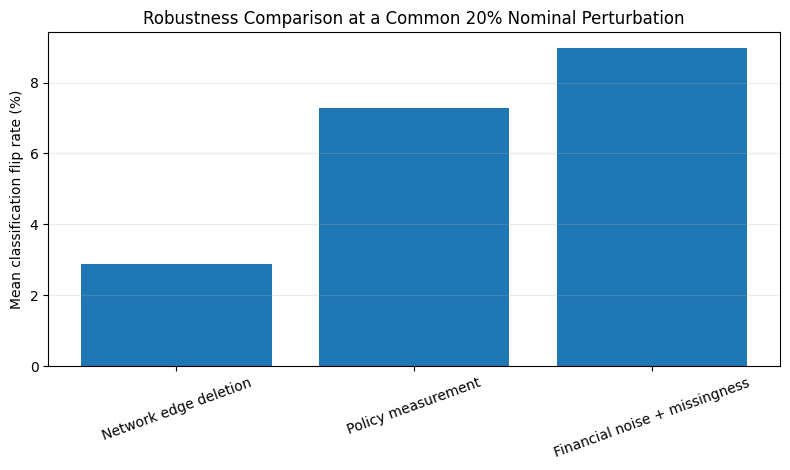

In [15]:
# Common 20% comparison figure

fig, ax = plt.subplots(figsize=(8, 4.8))
plot_df = robustness_summary.sort_values("classification_flip_rate_mean")

ax.bar(
    plot_df["uncertainty_source"],
    plot_df["classification_flip_rate_mean"] * 100,
)
ax.set_ylabel("Mean classification flip rate (%)")
ax.set_title("Robustness Comparison at a Common 20% Nominal Perturbation")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(
    "module4_fig4_common20_comparison.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


In [16]:
# F2. Final output audit

expected_outputs = [
    "module4_lineage_check.csv",
    "module4_policy_uncertainty.csv",
    "module4_network_uncertainty.csv",
    "module4_financial_uncertainty.csv",
    "module4_credit_review_priority.csv",
    "module4_robustness_summary.csv",
    "module4_fig1_policy_uncertainty.png",
    "module4_fig2_network_uncertainty.png",
    "module4_fig3_financial_uncertainty.png",
    "module4_fig4_common20_comparison.png",
]

audit = pd.DataFrame({
    "output": expected_outputs,
    "exists": [Path(p).exists() for p in expected_outputs],
})
display(audit)

if not audit["exists"].all():
    missing_outputs = audit.loc[~audit["exists"], "output"].tolist()
    raise AssertionError(
        f"Module 4 finished with missing outputs: {missing_outputs}"
    )

print("Module 4 completed successfully.")


,output,exists
0,module4_lineage_check.csv,True
1,module4_policy_uncertainty.csv,True
2,module4_network_uncertainty.csv,True
3,module4_financial_uncertainty.csv,True
4,module4_credit_review_priority.csv,True
5,module4_robustness_summary.csv,True
6,module4_fig1_policy_uncertainty.png,True
7,module4_fig2_network_uncertainty.png,True
8,module4_fig3_financial_uncertainty.png,True
9,module4_fig4_common20_comparison.png,True


Module 4 completed successfully.
